<a href="https://colab.research.google.com/github/SSK-KGP/Customer-Churn-Prediction/blob/main/TelcoChurnIBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import kagglehub

os.environ['KAGGLE_USERNAME'] = "<Your Username>"
os.environ['KAGGLE_KEY'] = "<Your Kaggle Key>"

from google.colab import drive

drive.mount('/content/drive', force_remount=True)
BASE_PATH = '/content/drive/MyDrive/TelcoChurnIBM/'
os.makedirs(BASE_PATH, exist_ok=True)

Mounted at /content/drive


In [2]:
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

Using Colab cache for faster access to the 'telco-customer-churn-ibm-dataset' dataset.


In [3]:
for file in os.listdir(path):
    print(file)

Telco_customer_churn.xlsx


In [4]:
import shutil

source_file_path = os.path.join(path, "Telco_customer_churn.xlsx")

destination_file_path = BASE_PATH + "Telco_customer_churn.xlsx"

xlsx_file = shutil.copy(source_file_path, destination_file_path)

In [5]:
import pandas as pd

df = pd.read_excel(xlsx_file)

df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [7]:
df['Churn Reason']

,Churn Reason
0,Competitor made better offer
1,Moved
2,Moved
3,Moved
4,Competitor had better devices
...,...
7038,NaN
7039,NaN
7040,NaN
7041,NaN


In [8]:
df['Churn Reason'].value_counts()

,count
Churn Reason,
Attitude of support person,192
Competitor offered higher download speeds,189
Competitor offered more data,162
Don't know,154
Competitor made better offer,140
Attitude of service provider,135
Competitor had better devices,130
Network reliability,103
Product dissatisfaction,102


In [9]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [10]:
for columns in df.columns:
  print(df[columns].value_counts())
  print("\n\n")

CustomerID
3186-AJIEK    1
3668-QPYBK    1
9237-HQITU    1
7203-OYKCT    1
9837-FWLCH    1
             ..
1066-JKSGK    1
8779-QRDMV    1
4190-MFLUW    1
0280-XJGEX    1
7892-POOKP    1
Name: count, Length: 7043, dtype: int64



Count
1    7043
Name: count, dtype: int64



Country
United States    7043
Name: count, dtype: int64



State
California    7043
Name: count, dtype: int64



City
Los Angeles      305
San Diego        150
San Jose         112
Sacramento       108
San Francisco    104
                ... 
Chester            4
Big Bar            4
Washington         4
Stonyford          4
Stirling City      4
Name: count, Length: 1129, dtype: int64



Zip Code
92284    5
92275    5
92268    5
90710    5
90704    5
        ..
96104    4
96097    4
96094    4
96090    4
96085    4
Name: count, Length: 1652, dtype: int64



Lat Long
34.159534, -116.425984    5
33.28156, -115.955541     5
34.201108, -116.593456    5
33.798266, -118.300237    5
33.391181, -118.421305    5
           

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [12]:
import matplotlib.pyplot as plt
import numpy as np

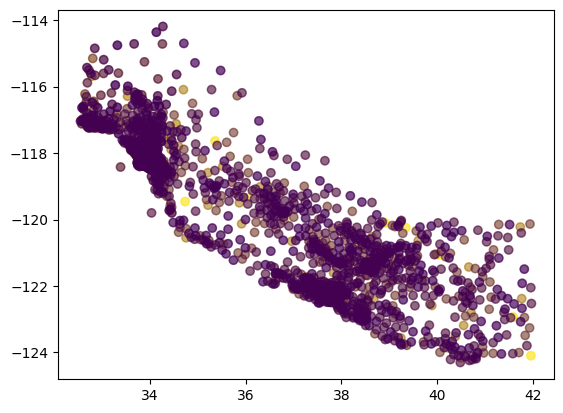

In [13]:
plt.scatter(df['Latitude'], df['Longitude'], c = df['Churn Value'], alpha = 0.25)

In [14]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors = 'coerce')

In [15]:
print(df['Total Charges'].isnull().sum())

11


In [16]:
dummydf = df.dropna()
corr = np.corrcoef(dummydf['Monthly Charges']*dummydf['Tenure Months'], dummydf['Total Charges'])
print(corr)

[[1.         0.99956572]
 [0.99956572 1.        ]]


In [17]:
dropcols = ['Country', 'State', 'Count', 'CustomerID', 'Zip Code', 'City', 'Latitude', 'Longitude', 'Lat Long', 'Churn Label', 'Churn Reason', 'Churn Score', 'CLTV', 'Total Charges']

In [18]:
(df['Churn Label'].map({'Yes':1, 'No':0}) == df['Churn Value']).all()

np.True_

In [19]:
newdf = df.drop(columns = dropcols)

In [20]:
newdf

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,0
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,0
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,0
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,0


In [21]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

X_lr = newdf.drop(columns = 'Churn Value')
y_lr = newdf['Churn Value']

categorical = X_lr.columns.tolist()

numerical = ['Tenure Months', 'Monthly Charges']
for col in numerical:
  categorical.remove(col)

trf = ColumnTransformer([
    ('ohe', OneHotEncoder(drop = 'first', sparse_output = False), categorical)
], remainder = 'passthrough')

lr_pipe = Pipeline([
    ('trf', trf),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression())
])

In [22]:
from sklearn.model_selection import train_test_split

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size = 0.2, random_state = 42)

In [23]:
lr_pipe.fit(X_train_lr, y_train_lr)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('trf',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('scaler', StandardScaler()), ('lr', LogisticRegression())])

In [24]:
y_pred_lr = lr_pipe.predict(X_test_lr)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_test_lr, y_pred_lr))
print(confusion_matrix(y_test_lr, y_pred_lr))

0.8026969481902059
[[901 108]
 [170 230]]


In [26]:
print(classification_report(y_test_lr, y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.57      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [27]:
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test_lr, y_pred_lr))
with open(BASE_PATH + "noncv_model_classification_report.txt", "w") as f:
  f.write(classification_report(y_test_lr, y_pred_lr))
  f.write(f'\nAccuracy_Score: {accuracy_score(y_test_lr, y_pred_lr)}\n')
  f.write(f'ROC_AUC_Score: {roc_auc_score(y_test_lr, y_pred_lr)}\n')
  f.write(f'Confusion_Matrix: {confusion_matrix(y_test_lr, y_pred_lr)}\n')

0.7339816650148662


In [28]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
score_acc = cross_val_score(lr_pipe, X_lr, y_lr, cv = cv, scoring = 'accuracy').mean()
score_roc_auc = cross_val_score(lr_pipe, X_lr, y_lr, cv = cv, scoring = 'roc_auc').mean()
print(score_acc, score_roc_auc)

0.8086047890186464 0.8560990743523099


In [29]:
y_prob_lr = lr_pipe.predict_proba(X_test_lr)[:, 1]
y_churnscore_lr = y_prob_lr * 100


In [30]:
label_df = y_test_lr.to_frame()
label_df['Churn Score'] = y_churnscore_lr
label_df['Predict'] = y_pred_lr

In [31]:
label_df

,Churn Value,Churn Score,Predict
185,1,55.825621,1
2715,0,30.542353,0
3825,0,26.064983,0
1807,1,76.749294,1
132,1,33.189151,0
...,...,...,...
6366,0,8.445772,0
315,1,61.107489,1
2439,0,64.478754,1
5002,0,2.412963,0


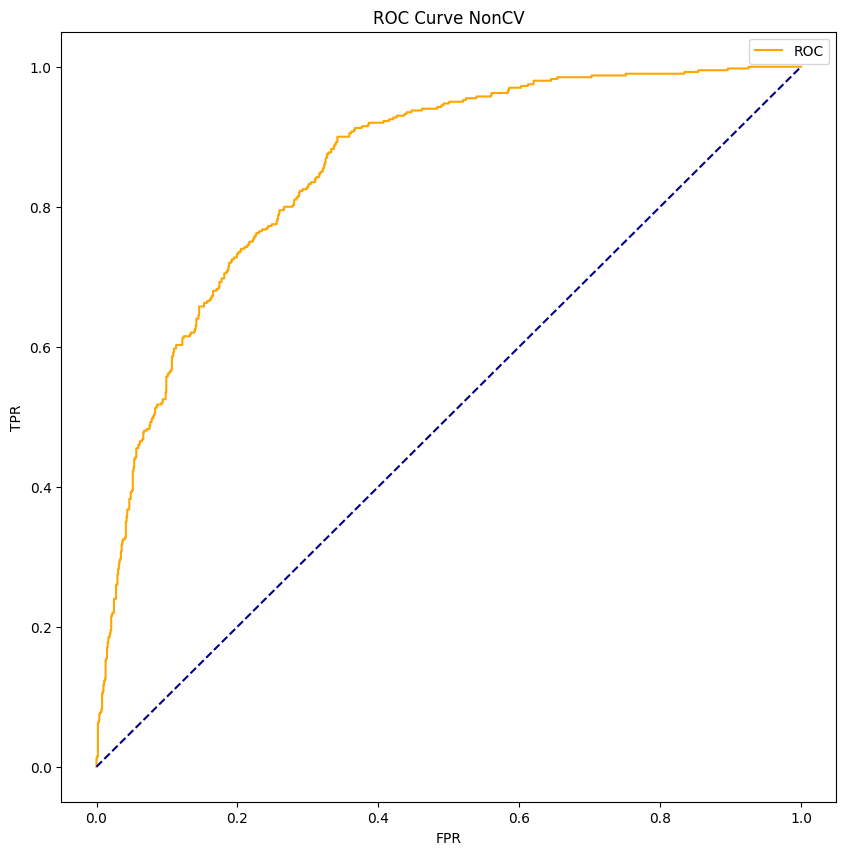

In [32]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test_lr, y_churnscore_lr)

fig, ax = plt.subplots(figsize = (10, 10))
ax.plot(fpr, tpr, color = 'orange', label = 'ROC')
ax.plot([0, 1], [0, 1], color = 'darkblue', linestyle = '--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ROC Curve NonCV')
ax.legend()
fig.savefig(BASE_PATH + 'roc_curve_noncv.png')
plt.show()

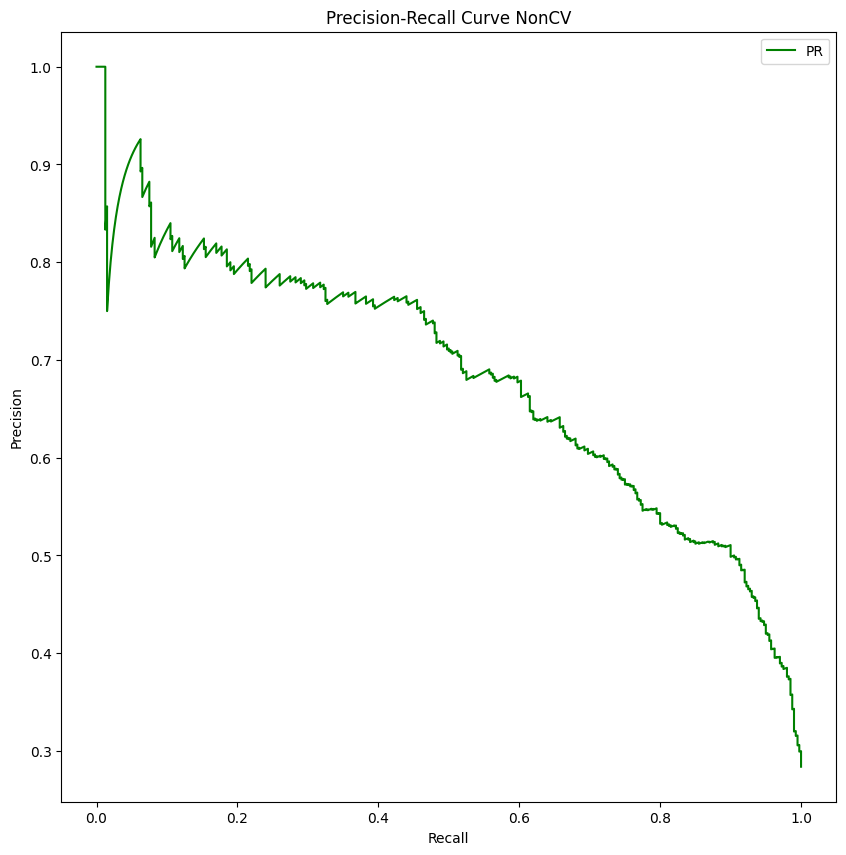

In [33]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test_lr, y_churnscore_lr)

figu, axe = plt.subplots(figsize = (10, 10))
axe.plot(recall, precision, color = 'green', label = 'PR')
axe.set_xlabel('Recall')
axe.set_ylabel('Precision')
axe.set_title(f'Precision-Recall Curve NonCV')
axe.legend()
figu.savefig(BASE_PATH + 'pr_curve_noncv.png')
plt.show()

In [34]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_test_lr, y_churnscore_lr)
print(ap)

0.6830287340364765


In [35]:
from sklearn.model_selection import cross_val_predict

y_predict_lr = cross_val_predict(
    lr_pipe,
    X_lr,
    y_lr,
    cv=cv
)

print(classification_report(y_lr, y_predict_lr))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      5174
           1       0.66      0.57      0.61      1869

    accuracy                           0.81      7043
   macro avg       0.76      0.73      0.74      7043
weighted avg       0.80      0.81      0.80      7043



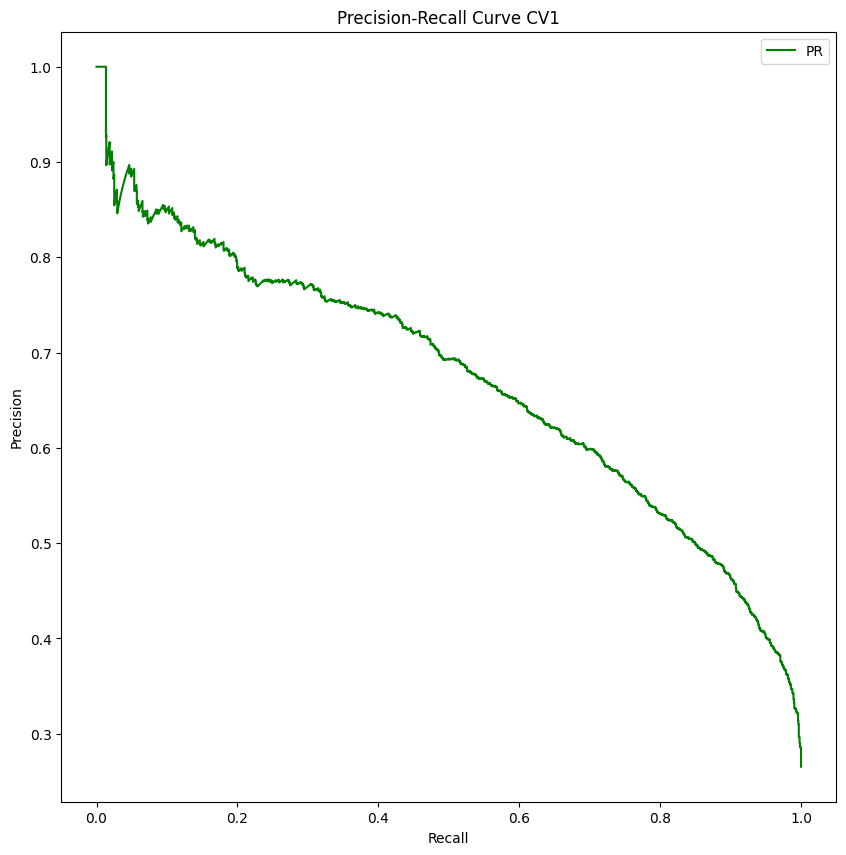

In [36]:
y_predict_proba_lr = cross_val_predict(
    lr_pipe,
    X_lr,
    y_lr,
    cv=cv,
    method='predict_proba'
)

y_predict_proba_lr = y_predict_proba_lr[:, 1]

y_predict_churnscore_lr = y_predict_proba_lr * 100

precision, recall, thresholds = precision_recall_curve(y_lr, y_predict_churnscore_lr)

figu, axe = plt.subplots(figsize = (10, 10))
axe.plot(recall, precision, color = 'green', label = 'PR')
axe.set_xlabel('Recall')
axe.set_ylabel('Precision')
axe.set_title(f'Precision-Recall Curve CV1')
axe.legend()
figu.savefig(BASE_PATH + 'pr_cv1.png')
plt.show()

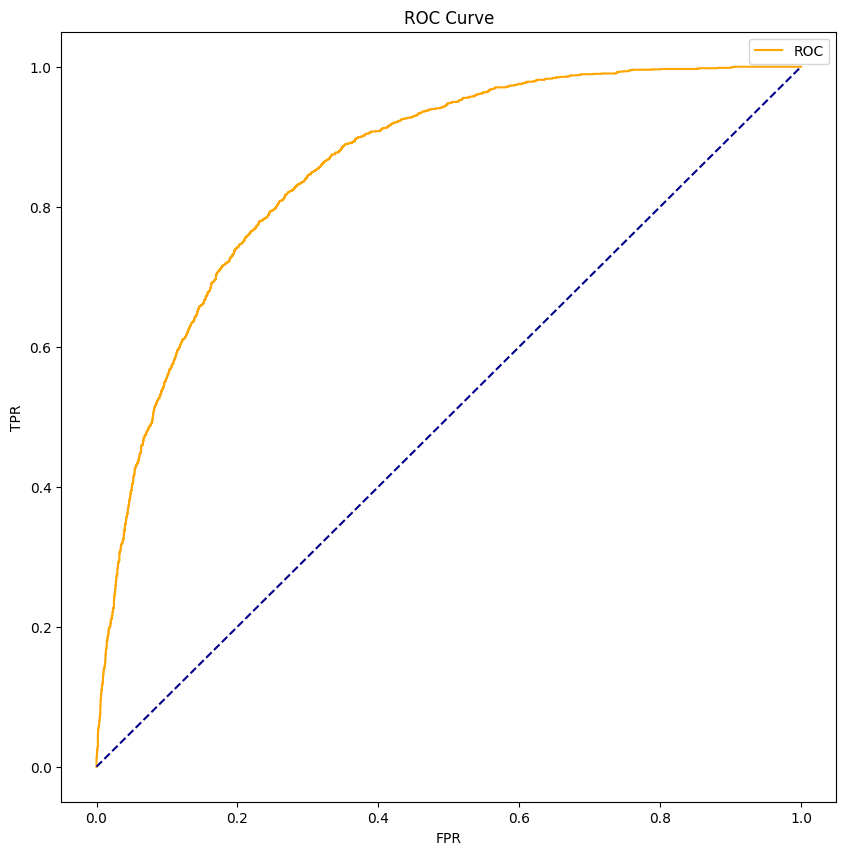

In [37]:
fpr, tpr, thresholds1 = roc_curve(y_lr, y_predict_churnscore_lr)

fig, ax = plt.subplots(figsize = (10, 10))
ax.plot(fpr, tpr, color = 'orange', label = 'ROC')
ax.plot([0, 1], [0, 1], color = 'darkblue', linestyle = '--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ROC Curve')
ax.legend()
fig.savefig(BASE_PATH + 'roc_curve_cv1.png')
plt.show()

In [38]:
optimal = np.argmax(tpr - fpr)
optimal_threshold = thresholds1[optimal]
print(optimal_threshold)

25.208570037753724


In [39]:
f1_score_lr = 2 * precision * recall / (precision + recall + 1e-10)
optimal_ind = np.argmax(f1_score_lr)
optimal_threshold_lr = thresholds[optimal_ind]
print(optimal_threshold_lr)

36.81235122450398


In [40]:
y_pred_lr_with_thresholds = (y_predict_churnscore_lr >= optimal_threshold_lr).astype(int)

In [41]:
y_pred_lr_with_thresholds

array([0, 0, 1, ..., 0, 0, 0])

In [42]:
print(accuracy_score(y_lr, y_pred_lr_with_thresholds))
print(confusion_matrix(y_lr, y_pred_lr_with_thresholds))
print(classification_report(y_lr, y_pred_lr_with_thresholds))


with open(BASE_PATH + "CV1_model_classification_report.txt", "w") as f:
  f.write(classification_report(y_lr, y_predict_lr))
  f.write(f'\nAccuracy_Score: {accuracy_score(y_lr, y_predict_lr)}\n')
  f.write(f'ROC_AUC_Score: {roc_auc_score(y_lr, y_predict_lr)}\n')
  f.write(f'Confusion_Matrix: {confusion_matrix(y_lr, y_predict_lr)}\n')

with open(BASE_PATH + f"CV_Threshold({optimal_threshold_lr:.2f}-MaxF1)_model_classification_report.txt", "w") as f:
  f.write(classification_report(y_lr, y_pred_lr_with_thresholds))
  f.write(f'\nAccuracy_Score: {accuracy_score(y_lr, y_pred_lr_with_thresholds)}\n')
  f.write(f'ROC_AUC_Score: {roc_auc_score(y_lr, y_pred_lr_with_thresholds)}\n')
  f.write(f'Confusion_Matrix: {confusion_matrix(y_lr, y_pred_lr_with_thresholds)}\n')

0.7949737327843248
[[4271  903]
 [ 541 1328]]
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      5174
           1       0.60      0.71      0.65      1869

    accuracy                           0.79      7043
   macro avg       0.74      0.77      0.75      7043
weighted avg       0.81      0.79      0.80      7043



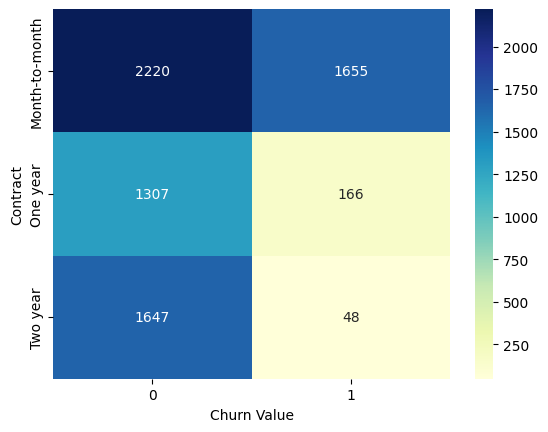

In [43]:
import seaborn as sns

grid = pd.crosstab(X_lr['Contract'], y_lr)
sns.heatmap(grid, annot=True, fmt='d', cmap='YlGnBu')
plt.savefig(BASE_PATH + 'contract_vs_churn.png')

56.73510324483776
0
72
79
13.5 105.5 48.0 71.0 64.0
60.770412979351036
30.81645569620253


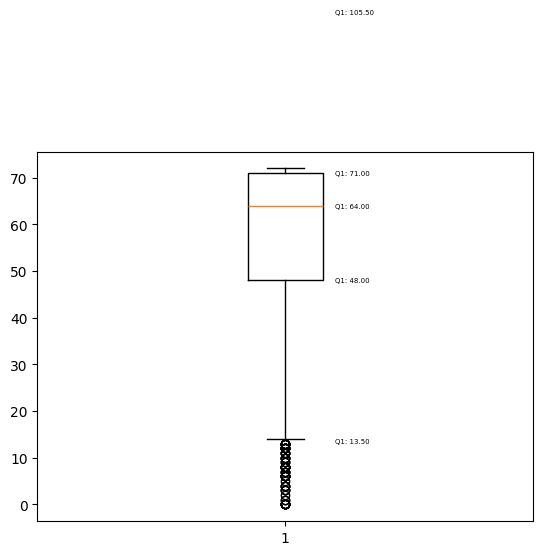

In [44]:
print(df[df['Contract'] == 'Two year']['Tenure Months'].mean())
print(df[df['Contract'] == 'Two year']['Tenure Months'].min())
print(df[df['Contract'] == 'Two year']['Tenure Months'].max())
plt.boxplot(df[df['Contract'] == 'Two year']['Tenure Months'])
q1_2 = df[df['Contract'] == 'Two year']['Tenure Months'].quantile(0.25)
q3_2 = df[df['Contract'] == 'Two year']['Tenure Months'].quantile(0.75)
med_2 = df[df['Contract'] == 'Two year']['Tenure Months'].median()
min_2 = q1_2 - 1.5 * (q3_2 - q1_2)
max_2 = q3_2 + 1.5 * (q3_2 - q1_2)
print(df[(df['Contract'] == 'Two year') & (df['Tenure Months'] < min_2)]['Tenure Months'].count())
print(min_2, max_2, q1_2, q3_2, med_2)
plt.text(1.1, q1_2, f'Q1: {q1_2:.2f}', va='center', size = 5)
plt.text(1.1, med_2, f'Q1: {med_2:.2f}', va='center', size = 5)
plt.text(1.1, q3_2, f'Q1: {q3_2:.2f}', va='center', size = 5)
plt.text(1.1, max_2, f'Q1: {max_2:.2f}', va='center', size = 5)
plt.text(1.1, min_2, f'Q1: {min_2:.2f}', va='center', size = 5)
plt.savefig(BASE_PATH + 'TwoYear_box.png')
print(df[df['Contract'] == 'Two year']['Monthly Charges'].mean())
print(df[(df['Contract'] == 'Two year') & (df['Tenure Months'] < min_2)]['Monthly Charges'].mean())

42.044806517311606
0
72
-19.5 104.5 27.0 58.0 44.0


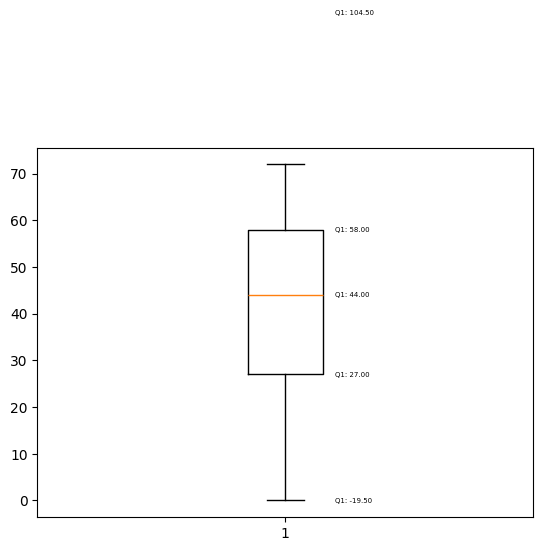

In [45]:
print(df[df['Contract'] == 'One year']['Tenure Months'].mean())
print(df[df['Contract'] == 'One year']['Tenure Months'].min())
print(df[df['Contract'] == 'One year']['Tenure Months'].max())
plt.boxplot(df[df['Contract'] == 'One year']['Tenure Months'])
q1_1 = df[df['Contract'] == 'One year']['Tenure Months'].quantile(0.25)
q3_1 = df[df['Contract'] == 'One year']['Tenure Months'].quantile(0.75)
med_1 = df[df['Contract'] == 'One year']['Tenure Months'].median()
min_1 = q1_1 - 1.5 * (q3_1 - q1_1)
max_1 = q3_1 + 1.5 * (q3_1 - q1_1)
plt.text(1.1, q1_1, f'Q1: {q1_1:.2f}', va='center', size = 5)
plt.text(1.1, med_1, f'Q1: {med_1:.2f}', va='center', size = 5)
plt.text(1.1, q3_1, f'Q1: {q3_1:.2f}', va='center', size = 5)
plt.text(1.1, max_1, f'Q1: {max_1:.2f}', va='center', size = 5)
plt.text(1.1, 0, f'Q1: {min_1:.2f}', va='center', size = 5)
plt.savefig(BASE_PATH + 'OneYear_box.png')
print(min_1, max_1, q1_1, q3_1, med_1)

18.036645161290323
1
72
17
-36.0 68.0 3.0 29.0 12.0
66.39849032258064
95.3970588235294


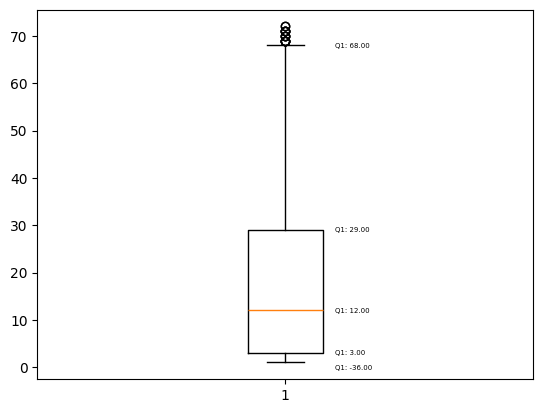

In [46]:
print(df[df['Contract'] == 'Month-to-month']['Tenure Months'].mean())
print(df[df['Contract'] == 'Month-to-month']['Tenure Months'].min())
print(df[df['Contract'] == 'Month-to-month']['Tenure Months'].max())
plt.boxplot(df[df['Contract'] == 'Month-to-month']['Tenure Months'])
q1_0 = df[df['Contract'] == 'Month-to-month']['Tenure Months'].quantile(0.25)
q3_0 = df[df['Contract'] == 'Month-to-month']['Tenure Months'].quantile(0.75)
med_0 = df[df['Contract'] == 'Month-to-month']['Tenure Months'].median()
max_0 = q3_0 + 1.5 * (q3_0 - q1_0)
min_0 = q1_0 - 1.5 * (q3_0 - q1_0)
print(df[(df['Contract'] == 'Month-to-month') & (df['Tenure Months'] > max_0)]['Tenure Months'].count())
print(min_0, max_0, q1_0, q3_0, med_0)
plt.text(1.1, q1_0, f'Q1: {q1_0:.2f}', va='center', size = 5)
plt.text(1.1, med_0, f'Q1: {med_0:.2f}', va='center', size = 5)
plt.text(1.1, q3_0, f'Q1: {q3_0:.2f}', va='center', size = 5)
plt.text(1.1, max_0, f'Q1: {max_0:.2f}', va='center', size = 5)
plt.text(1.1, 0, f'Q1: {min_0:.2f}', va='center', size = 5)
plt.savefig(BASE_PATH + 'Month-to-Month_box.png')
print(df[df['Contract'] == 'Month-to-month']['Monthly Charges'].mean())
print(df[(df['Contract'] == 'Month-to-month') & (df['Tenure Months'] > max_0)]['Monthly Charges'].mean())

In [47]:
X_lr.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges']

In [48]:
Demographics = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']
Behavior = ['Tenure Months', 'Contract', 'Paperless Billing', 'Payment Method']
Services = ['Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
Charges = ['Monthly Charges']

In [49]:
new_lr_pipe = Pipeline([
    ('trf', trf),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(penalty = 'l1', solver = 'liblinear', C = 0.1))
])

In [50]:
new_lr_pipe.fit(X_train_lr, y_train_lr)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('trf',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('scaler', StandardScaler()),
                ('lr',
                 LogisticRegression(C=0.1, penalty='l1', solver='liblinear'))])

In [51]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
score_acc_new = cross_val_score(new_lr_pipe, X_lr, y_lr, cv = cv, scoring = 'accuracy').mean()
score_roc_auc_new = cross_val_score(new_lr_pipe, X_lr, y_lr, cv = cv, scoring = 'roc_auc').mean()
print(score_acc_new, score_roc_auc_new)

0.8093147138525065 0.8561387333236272


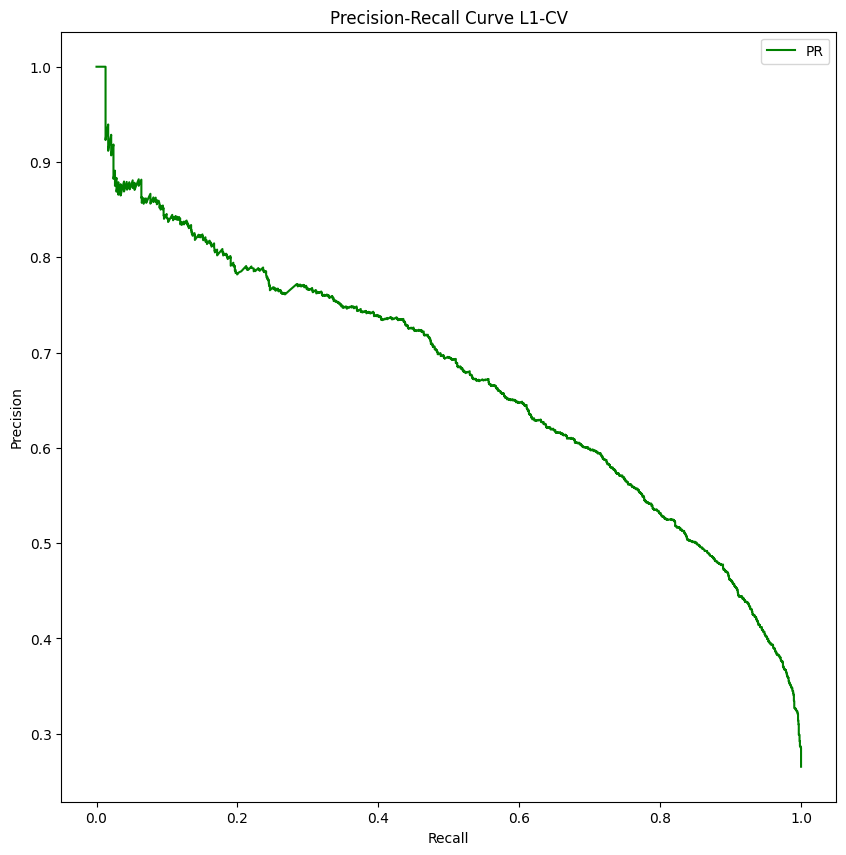

In [52]:
y_predict_proba_lr_new = cross_val_predict(
    new_lr_pipe,
    X_lr,
    y_lr,
    cv=cv,
    method='predict_proba'
)

y_predict_proba_lr_new = y_predict_proba_lr_new[:, 1]

y_predict_churnscore_lr_new = y_predict_proba_lr_new * 100

precision_new, recall_new, thresholds_new = precision_recall_curve(y_lr, y_predict_churnscore_lr_new)

figu, axe = plt.subplots(figsize = (10, 10))
axe.plot(recall_new, precision_new, color = 'green', label = 'PR')
axe.set_xlabel('Recall')
axe.set_ylabel('Precision')
axe.set_title(f'Precision-Recall Curve L1-CV')
axe.legend()
figu.savefig(BASE_PATH + 'pr_l1_cv.png')
plt.show()

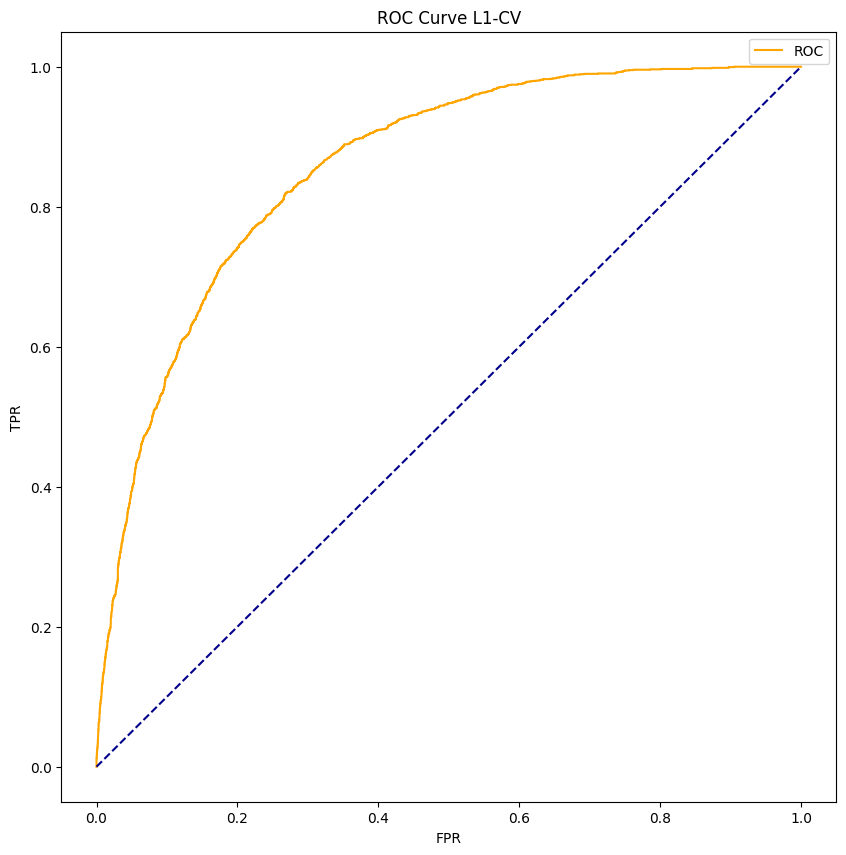

In [53]:
fpr_new, tpr_new, thresholds1_new = roc_curve(y_lr, y_predict_churnscore_lr_new)

fig, ax = plt.subplots(figsize = (10, 10))
ax.plot(fpr_new, tpr_new, color = 'orange', label = 'ROC')
ax.plot([0, 1], [0, 1], color = 'darkblue', linestyle = '--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ROC Curve L1-CV')
ax.legend()
fig.savefig(BASE_PATH + 'roc_curve_l1_cv.png')
plt.show()

In [54]:
y_predict_lr_new = cross_val_predict(
    new_lr_pipe,
    X_lr,
    y_lr,
    cv=cv
)

print(classification_report(y_lr, y_predict_lr_new))
print(accuracy_score(y_lr, y_predict_lr_new))
print(confusion_matrix(y_lr, y_predict_lr_new))
print(roc_auc_score(y_lr, y_predict_lr_new))

with open(BASE_PATH + "CV_L1_model_classification_report.txt", "w") as f:
  f.write(classification_report(y_lr, y_predict_lr_new))
  f.write(f'\nAccuracy_Score: {accuracy_score(y_lr, y_predict_lr_new)}\n')
  f.write(f'ROC_AUC_Score: {roc_auc_score(y_lr, y_predict_lr_new)}\n')
  f.write(f'Confusion_Matrix: {confusion_matrix(y_lr, y_predict_lr_new)}\n')

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      5174
           1       0.67      0.57      0.61      1869

    accuracy                           0.81      7043
   macro avg       0.76      0.73      0.74      7043
weighted avg       0.80      0.81      0.80      7043

0.8093142126934545
[[4642  532]
 [ 811 1058]]
0.7316281576628253


In [55]:
optimal_new = np.argmax(tpr_new - fpr_new)
optimal_threshold_new = thresholds1_new[optimal_new]
print(optimal_threshold_new)

25.513477147224933


In [56]:
f1_score_lr_new = 2 * precision_new * recall_new / (precision_new + recall_new + 1e-10)
optimal_ind_new = np.argmax(f1_score_lr_new)
optimal_threshold_lr_new = thresholds[optimal_ind_new]
print(optimal_threshold_lr_new)

32.58219769077431


In [57]:
classifier = new_lr_pipe.named_steps['lr']
weights = classifier.coef_[0]
print(weights)

[-2.64627480e-03  3.57571143e-02  1.01254696e-01 -5.71293486e-01
 -5.45483030e-02  4.32167452e-02  1.50527127e-01  3.88832161e-01
 -1.74183317e-02 -7.52075502e-05 -1.53251374e-01  0.00000000e+00
 -9.19634189e-03  0.00000000e+00  8.68039618e-03 -8.04218091e-02
 -1.31751056e-01 -9.79143122e-02  1.20826100e-01 -1.26082403e-01
  9.27593249e-02 -2.32679216e-01 -5.20806481e-01  1.76824562e-01
 -4.16475140e-02  1.48967382e-01  0.00000000e+00 -8.76453576e-01
  0.00000000e+00]


In [58]:
ohe_names = new_lr_pipe.named_steps['trf'].named_transformers_['ohe'].get_feature_names_out(categorical)
print(ohe_names)

['Gender_Male' 'Senior Citizen_Yes' 'Partner_Yes' 'Dependents_Yes'
 'Phone Service_Yes' 'Multiple Lines_No phone service'
 'Multiple Lines_Yes' 'Internet Service_Fiber optic' 'Internet Service_No'
 'Online Security_No internet service' 'Online Security_Yes'
 'Online Backup_No internet service' 'Online Backup_Yes'
 'Device Protection_No internet service' 'Device Protection_Yes'
 'Tech Support_No internet service' 'Tech Support_Yes'
 'Streaming TV_No internet service' 'Streaming TV_Yes'
 'Streaming Movies_No internet service' 'Streaming Movies_Yes'
 'Contract_One year' 'Contract_Two year' 'Paperless Billing_Yes'
 'Payment Method_Credit card (automatic)'
 'Payment Method_Electronic check' 'Payment Method_Mailed check']


In [59]:
X_lr.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges'],
      dtype='object')

In [60]:
ohe_names = list(ohe_names) + ['Tenure Months', 'Monthly Charges']
print(ohe_names)
print(len(ohe_names))

['Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check', 'Tenure Months', 'Monthly Charges']
29


In [61]:
feature_importances = dict(zip(ohe_names, weights))

for name, wt in feature_importances.items():
  print(f'{name}:\t| {wt}\n')

with open(BASE_PATH + "Feature_Importances_L1_LogisticRegression.txt", "w") as f:
  for name, wt in feature_importances.items():
    f.write(f'{name}:\t| {wt}\n')

Gender_Male:	| -0.0026462748018200133

Senior Citizen_Yes:	| 0.03575711428035266

Partner_Yes:	| 0.10125469552383308

Dependents_Yes:	| -0.5712934856801937

Phone Service_Yes:	| -0.054548303020925656

Multiple Lines_No phone service:	| 0.04321674517140039

Multiple Lines_Yes:	| 0.1505271267272631

Internet Service_Fiber optic:	| 0.3888321613180771

Internet Service_No:	| -0.017418331680868628

Online Security_No internet service:	| -7.52075501915996e-05

Online Security_Yes:	| -0.15325137362935046

Online Backup_No internet service:	| 0.0

Online Backup_Yes:	| -0.009196341892987969

Device Protection_No internet service:	| 0.0

Device Protection_Yes:	| 0.00868039617748974

Tech Support_No internet service:	| -0.0804218090827192

Tech Support_Yes:	| -0.1317510561140903

Streaming TV_No internet service:	| -0.09791431222106445

Streaming TV_Yes:	| 0.12082609960504687

Streaming Movies_No internet service:	| -0.12608240348191982

Streaming Movies_Yes:	| 0.09275932490335326

Contract_One y

In [62]:
intercept = classifier.intercept_[0]
print(intercept)

-1.7052433491585097


In [63]:
y_predict_churnscore_lr_new

array([30.98141246, 37.16277452, 45.95200659, ...,  4.1291631 ,
       19.83655877,  5.28947102])

In [64]:
y_pred_lr_with_thresholds_new = (y_predict_churnscore_lr_new >= optimal_threshold_lr_new).astype(int)

In [65]:
print(accuracy_score(y_lr, y_pred_lr_with_thresholds_new))
print(confusion_matrix(y_lr, y_pred_lr_with_thresholds_new))
print(classification_report(y_lr, y_pred_lr_with_thresholds_new))

with open(BASE_PATH + f"CV_L1_Threshold({optimal_threshold_lr_new:.2f}-MaxF1)_model_classification_report.txt", "w") as f:
  f.write(classification_report(y_lr, y_pred_lr_with_thresholds_new))
  f.write(f'\nAccuracy_Score: {accuracy_score(y_lr, y_pred_lr_with_thresholds_new)}\n')
  f.write(f'ROC_AUC_Score: {roc_auc_score(y_lr, y_pred_lr_with_thresholds_new)}\n')
  f.write(f'Confusion_Matrix: {confusion_matrix(y_lr, y_pred_lr_with_thresholds_new)}\n')

0.7812011926735766
[[4099 1075]
 [ 466 1403]]
              precision    recall  f1-score   support

           0       0.90      0.79      0.84      5174
           1       0.57      0.75      0.65      1869

    accuracy                           0.78      7043
   macro avg       0.73      0.77      0.74      7043
weighted avg       0.81      0.78      0.79      7043



In [66]:
print(accuracy_score(y_lr, y_predict_lr_new))
print(confusion_matrix(y_lr, y_predict_lr_new))
print(classification_report(y_lr, y_predict_lr_new))

0.8093142126934545
[[4642  532]
 [ 811 1058]]
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      5174
           1       0.67      0.57      0.61      1869

    accuracy                           0.81      7043
   macro avg       0.76      0.73      0.74      7043
weighted avg       0.80      0.81      0.80      7043



In [67]:
!pip install optuna

In [68]:
import optuna
from sklearn.metrics import f1_score

In [69]:
def objective(trial):
  C = trial.suggest_float('C', 0.01, 1)
  t = trial.suggest_float('t', 0.1, 1)
  opt_pipe_lr = Pipeline([
      ('trf', trf),
      ('scaler', StandardScaler()),
      ('lr', LogisticRegression(penalty = 'l1', solver = 'liblinear', C = C))
  ])
  cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
  auc_roc_score = cross_val_score(opt_pipe_lr, X_lr, y_lr, cv = cv, scoring = 'roc_auc').mean()
  acc_score = cross_val_score(opt_pipe_lr, X_lr, y_lr, cv = cv, scoring = 'accuracy').mean()
  y_opt_churnscore_lr = cross_val_predict(
    opt_pipe_lr,
    X_lr,
    y_lr,
    cv=cv,
    method = 'predict_proba')[:, 1]
  y_opt_pred_lr = (y_opt_churnscore_lr >= t).astype(int)
  f1_score_lr_opt = f1_score(y_lr, y_opt_pred_lr)
  return f1_score_lr_opt

In [70]:
study = optuna.create_study(direction = 'maximize')
study.optimize(objective, n_trials = 50)

[I 2026-06-26 05:42:24,987] A new study created in memory with name: no-name-8537f4a6-02fd-4841-80c8-391abf57b08f
[I 2026-06-26 05:42:27,628] Trial 0 finished with value: 0.2401826484018265 and parameters: {'C': 0.6788818041878076, 't': 0.7517332511722048}. Best is trial 0 with value: 0.2401826484018265.
[I 2026-06-26 05:42:31,116] Trial 1 finished with value: 0.5798816568047337 and parameters: {'C': 0.25408821959815164, 't': 0.5583645521676809}. Best is trial 1 with value: 0.5798816568047337.
[I 2026-06-26 05:42:37,363] Trial 2 finished with value: 0.6483839373163565 and parameters: {'C': 0.9703257782141479, 't': 0.370126232374938}. Best is trial 2 with value: 0.6483839373163565.
[I 2026-06-26 05:42:41,553] Trial 3 finished with value: 0.6195976154992549 and parameters: {'C': 0.7667913964194855, 't': 0.17979466240072595}. Best is trial 2 with value: 0.6483839373163565.
[I 2026-06-26 05:42:45,720] Trial 4 finished with value: 0.6369747899159663 and parameters: {'C': 0.3336711402372454,

In [71]:
print(study.best_params)

{'C': 0.9703257782141479, 't': 0.370126232374938}


In [72]:
best_lr_pipe = Pipeline([
    ('trf', trf),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(penalty = 'l1', solver = 'liblinear', C = study.best_params['C']))
])

auc_roc_score_best = cross_val_score(best_lr_pipe, X_lr, y_lr, cv = cv, scoring = 'roc_auc').mean()
acc_score_best = cross_val_score(best_lr_pipe, X_lr, y_lr, cv = cv, scoring = 'accuracy').mean()
y_opt_churnscore_lr_best = cross_val_predict(
    best_lr_pipe,
    X_lr,
    y_lr,
    cv=cv,
    method = 'predict_proba')[:, 1]
y_opt_pred_lr_best = (y_opt_churnscore_lr_best >= study.best_params['t']).astype(int)
print(classification_report(y_lr, y_opt_pred_lr_best))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      5174
           1       0.60      0.71      0.65      1869

    accuracy                           0.80      7043
   macro avg       0.74      0.77      0.75      7043
weighted avg       0.81      0.80      0.80      7043



In [73]:
with open(BASE_PATH + f"CV_L1({study.best_params['C']:.2f})_Best_Threshold({study.best_params['t']:.2f}-MaxF1)_model_classification_report.txt", "w") as f:
  f.write(classification_report(y_lr, y_opt_pred_lr_best))
  f.write(f'\nAccuracy_Score: {accuracy_score(y_lr, y_opt_pred_lr_best)}\n')
  f.write(f'ROC_AUC_Score: {roc_auc_score(y_lr, y_opt_pred_lr_best)}\n')
  f.write(f'Confusion_Matrix: {confusion_matrix(y_lr, y_opt_pred_lr_best)}\n')

In [74]:
from sklearn.ensemble import RandomForestClassifier
!pip install xgboost

In [75]:
import xgboost as xgb

In [76]:
y = y_lr
X = X_lr

In [77]:
y

,Churn Value
0,1
1,1
2,1
3,1
4,1
...,...
7038,0
7039,0
7040,0
7041,0


In [78]:
X

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Female,No,No,No,72,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15
7039,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80
7040,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20
7041,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60


In [79]:
def obj(trial):
  classifier_name = trial.suggest_categorical('classifier', ['Random Forest', 'XGBoost'])
  t = trial.suggest_float('t', 0.2, 0.6)

  if classifier_name == 'Random Forest':
    n_estimators = trial.suggest_int('n_estimators', 50, 400)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    max_samples = trial.suggest_float('max_samples', 0.1, 1)
    max_features = trial.suggest_float('max_features', 0.1, 1)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    class_weight = trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None])
    pipe = Pipeline([
        ('trf', trf),
        ('rf', RandomForestClassifier(n_estimators = n_estimators, max_depth = max_depth, max_samples = max_samples, max_features = max_features, min_samples_split = min_samples_split, min_samples_leaf = min_samples_leaf, class_weight = class_weight, oob_score = True, n_jobs = -1, random_state = 42))
        ])

  else:
    n_estimators = trial.suggest_int('n_estimators', 50, 400)
    max_depth = trial.suggest_int('max_depth', 3, 30)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2)
    subsample = trial.suggest_float('subsample', 0.1, 1)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.1, 1)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    gamma = trial.suggest_float('gamma', 0, 1)
    reg_alpha = trial.suggest_float('reg_alpha', 0, 1)
    eval_metric = trial.suggest_categorical('eval_metric', ['auc', 'aucpr'])
    scale_pos_weight = (len(y) - sum(y)) / sum(y)
    pipe = Pipeline([
        ('trf', trf),
        ('xgb', xgb.XGBClassifier(n_estimators = n_estimators, max_depth = max_depth, learning_rate = learning_rate, subsample = subsample, colsample_bytree = colsample_bytree, min_child_weight = min_child_weight, gamma = gamma, reg_alpha = reg_alpha, eval_metric = eval_metric, use_label_encoding = False, n_jobs = -1, scale_pos_weight = scale_pos_weight, random_state = 42))
        ])

  y_predict_proba = cross_val_predict(pipe, X, y, cv=cv, method = 'predict_proba')[:, 1]
  y_pred = (y_predict_proba >= t).astype(int)
  return f1_score(y, y_pred)

In [80]:
study_new = optuna.create_study(direction = 'maximize')
study_new.optimize(obj, n_trials = 100)

[I 2026-06-26 05:44:51,072] A new study created in memory with name: no-name-9177ea4a-d9db-46c7-825c-d9b341664c29
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:44:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoding" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:44:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoding" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:45:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoding" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:45:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoding" } a

In [81]:
scale_pos_weight = (len(y) - sum(y)) / sum(y)

best_params = study_new.best_trial.params
classifier_name = best_params.pop('classifier')
threshold = best_params.pop('t')

if classifier_name == 'Random Forest':
  best_pipe = Pipeline([('trf', trf), (classifier_name, RandomForestClassifier(**best_params, oob_score = True, n_jobs = -1, random_state = 42))])
else:
  best_pipe = Pipeline([('trf', trf), (classifier_name, xgb.XGBClassifier(**best_params, use_label_encoding = False, n_jobs = -1, scale_pos_weight = scale_pos_weight, random_state = 42))])

y_predict_proba = cross_val_predict(best_pipe, X, y, cv=cv, method = 'predict_proba')[:, 1]

y_pred = (y_predict_proba >= threshold).astype(int)

In [82]:
print(classification_report(y, y_pred))
print(accuracy_score(y, y_pred))
print(roc_auc_score(y, y_pred))
print(confusion_matrix(y, y_pred))


with open(BASE_PATH + f"Best_threshold({threshold})_model_classification_report.txt", "w") as f:
  f.write(classification_report(y, y_pred))
  f.write(f'\nAccuracy_Score: {accuracy_score(y, y_pred)}\n')
  f.write(f'ROC_AUC_Score: {roc_auc_score(y, y_pred)}\n')
  f.write(f'Confusion_Matrix: {confusion_matrix(y, y_pred)}\n')

              precision    recall  f1-score   support

           0       0.90      0.81      0.85      5174
           1       0.58      0.75      0.66      1869

    accuracy                           0.79      7043
   macro avg       0.74      0.78      0.75      7043
weighted avg       0.82      0.79      0.80      7043

0.7924180036916086
0.7799383487797467
[[4173 1001]
 [ 461 1408]]


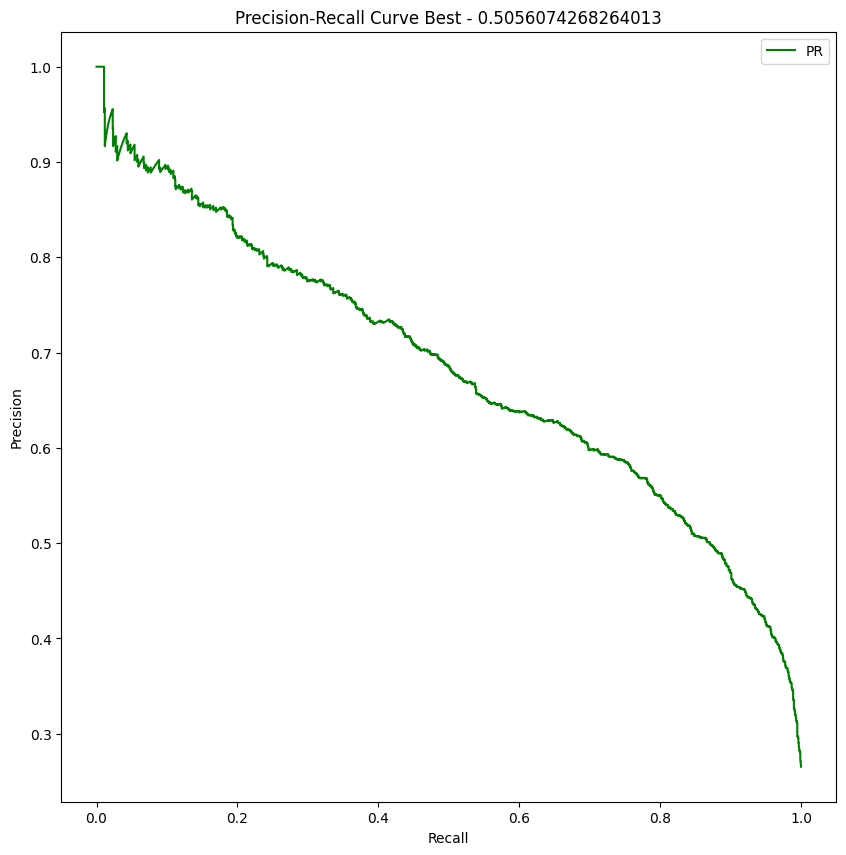

In [83]:
y_predict_proba = cross_val_predict(
    best_pipe,
    X,
    y,
    cv=cv,
    method='predict_proba'
)

y_predict_proba = y_predict_proba[:, 1]

y_predict_churnscore = y_predict_proba * 100

precision_best, recall_best, thresholds_best = precision_recall_curve(y, y_predict_churnscore)

figu, axe = plt.subplots(figsize = (10, 10))
axe.plot(recall_best, precision_best, color = 'green', label = 'PR')
axe.set_xlabel('Recall')
axe.set_ylabel('Precision')
axe.set_title(f'Precision-Recall Curve Best - {threshold}')
axe.legend()
figu.savefig(BASE_PATH + f'pr_best{threshold}.png')
plt.show()

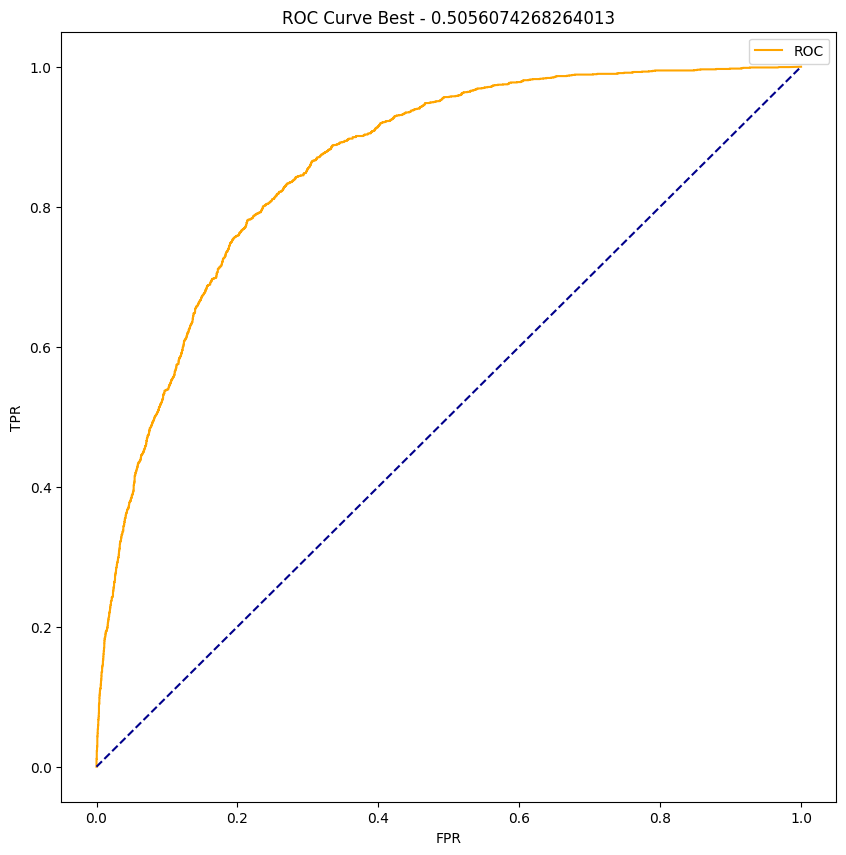

In [84]:
fpr_best, tpr_best, thresholds1_best = roc_curve(y, y_predict_churnscore)

fig, ax = plt.subplots(figsize = (10, 10))
ax.plot(fpr_best, tpr_best, color = 'orange', label = 'ROC')
ax.plot([0, 1], [0, 1], color = 'darkblue', linestyle = '--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title(f'ROC Curve Best - {threshold}')
ax.legend()
fig.savefig(BASE_PATH + f'roc_curve_best{threshold}.png')
plt.show()

In [85]:
import shap

In [86]:
preprocessor = best_pipe.named_steps['trf']
feature_names = preprocessor.get_feature_names_out()
print(feature_names)
print(len(feature_names))

['ohe__Gender_Male' 'ohe__Senior Citizen_Yes' 'ohe__Partner_Yes'
 'ohe__Dependents_Yes' 'ohe__Phone Service_Yes'
 'ohe__Multiple Lines_No phone service' 'ohe__Multiple Lines_Yes'
 'ohe__Internet Service_Fiber optic' 'ohe__Internet Service_No'
 'ohe__Online Security_No internet service' 'ohe__Online Security_Yes'
 'ohe__Online Backup_No internet service' 'ohe__Online Backup_Yes'
 'ohe__Device Protection_No internet service' 'ohe__Device Protection_Yes'
 'ohe__Tech Support_No internet service' 'ohe__Tech Support_Yes'
 'ohe__Streaming TV_No internet service' 'ohe__Streaming TV_Yes'
 'ohe__Streaming Movies_No internet service' 'ohe__Streaming Movies_Yes'
 'ohe__Contract_One year' 'ohe__Contract_Two year'
 'ohe__Paperless Billing_Yes'
 'ohe__Payment Method_Credit card (automatic)'
 'ohe__Payment Method_Electronic check' 'ohe__Payment Method_Mailed check'
 'remainder__Tenure Months' 'remainder__Monthly Charges']
29


In [91]:
import joblib
import json

joblib.dump(best_pipe, BASE_PATH + 'best_pipe.pkl')
metadata = {
    'threshold': threshold,
    'feature_names': best_pipe.named_steps['trf'].get_feature_names_out().tolist()
}
with open(BASE_PATH + 'metadata_best.json', 'w') as f:
  json.dump(metadata, f)

joblib.dump(best_lr_pipe, BASE_PATH + 'best_lr_pipe.pkl')
metadata_lr = {
    'threshold': study.best_params['t'],
    'feature_names': best_lr_pipe.named_steps['trf'].get_feature_names_out().tolist()
}
with open(BASE_PATH + 'metadata_best_lr.json', 'w') as f:
  json.dump(metadata_lr, f)

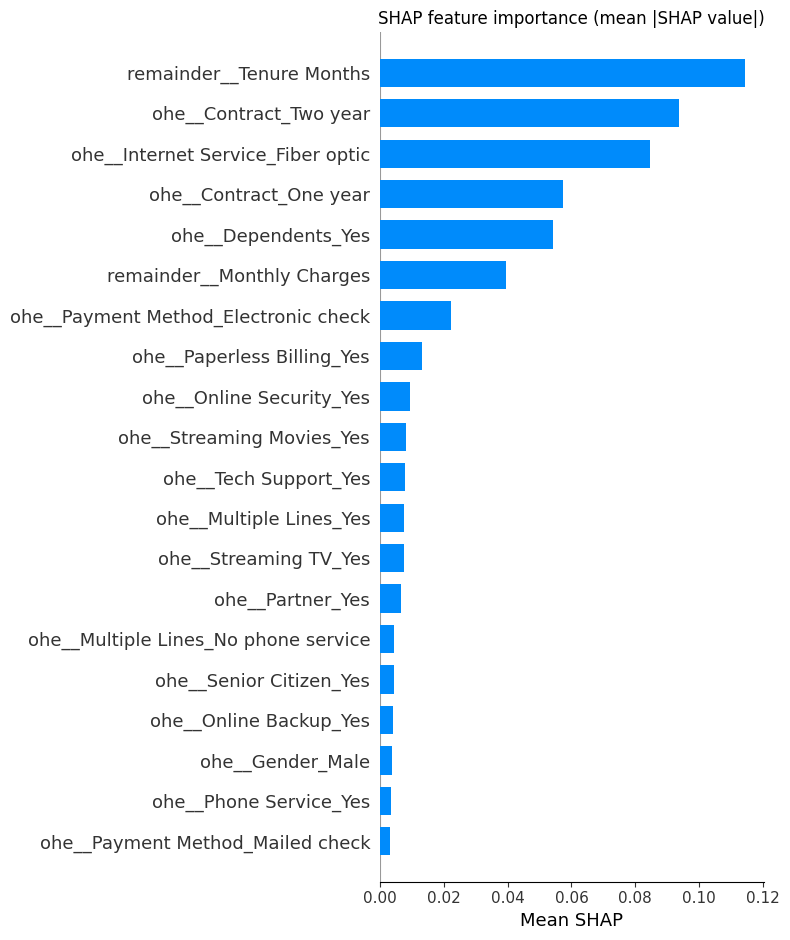

In [111]:
best_pipe.fit(X, y)
newX = preprocessor.transform(X)
newX = pd.DataFrame(newX, columns = feature_names)
explainer = shap.TreeExplainer(best_pipe.named_steps[classifier_name])
shap_values = explainer.shap_values(newX)
fig, ax = plt.subplots(figsize = (10, 6))
shap.summary_plot(shap_values[:, :, 1], newX, feature_names = feature_names, plot_type = 'bar', show = False)
plt.title('SHAP feature importance (mean |SHAP value|)')
plt.xlabel("Mean SHAP")
plt.tight_layout()
plt.savefig(BASE_PATH + f'shap_summary_plot_{classifier_name}.png')
plt.show()

In [107]:
shap_values

array([[[ 0.00637828, -0.00637828],
        [ 0.00323152, -0.00323152],
        [ 0.00254295, -0.00254295],
        ...,
        [ 0.01097957, -0.01097957],
        [-0.16993203,  0.16993203],
        [-0.00028136,  0.00028136]],

       [[-0.00483226,  0.00483226],
        [ 0.00160782, -0.00160782],
        [-0.02020079,  0.02020079],
        ...,
        [-0.0027469 ,  0.0027469 ],
        [-0.1878623 ,  0.1878623 ],
        [ 0.03802245, -0.03802245]],

       [[-0.00255607,  0.00255607],
        [ 0.00140323, -0.00140323],
        [-0.02499627,  0.02499627],
        ...,
        [-0.00169912,  0.00169912],
        [-0.09499746,  0.09499746],
        [-0.0402559 ,  0.0402559 ]],

       ...,

       [[ 0.00558151, -0.00558151],
        [ 0.00097867, -0.00097867],
        [ 0.00362683, -0.00362683],
        ...,
        [-0.00039336,  0.00039336],
        [ 0.17554974, -0.17554974],
        [-0.02186892,  0.02186892]],

       [[ 0.00241866, -0.00241866],
        [ 0.00329136, -0.00

In [110]:
shap_values[:, :, 1].shape

(7043, 29)

In [112]:
shap_values.shape

(7043, 29, 2)

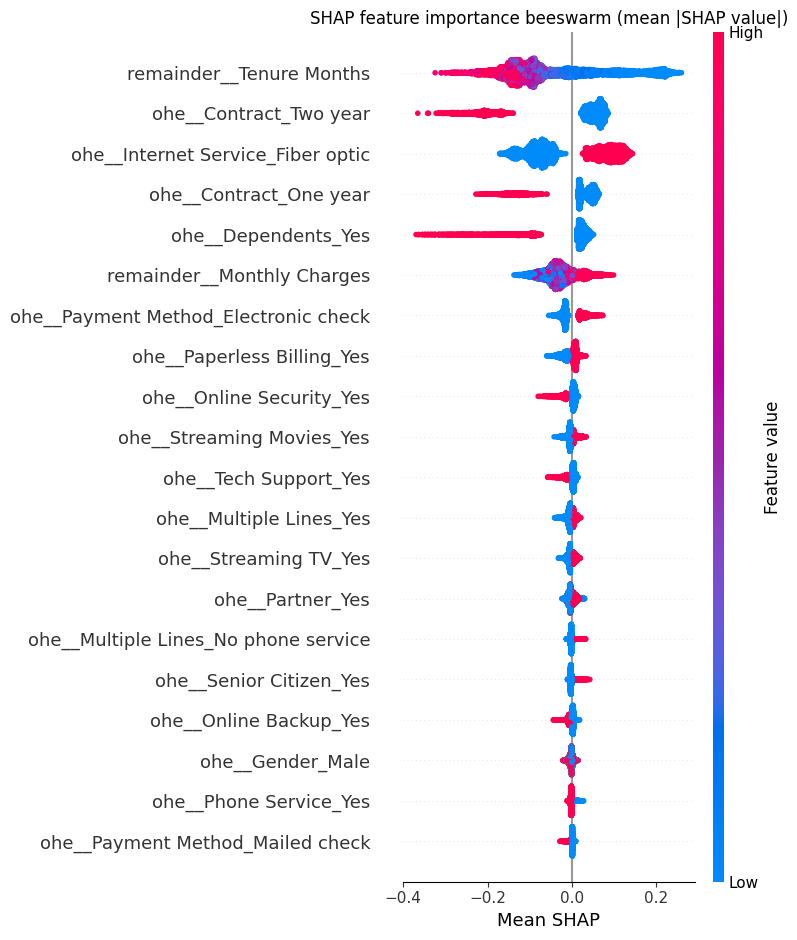

In [113]:
fig, ax = plt.subplots(figsize = (10, 6))
shap.summary_plot(shap_values[:, :, 1], newX, feature_names = feature_names, plot_type = 'dot', show = False)
plt.title('SHAP feature importance beeswarm (mean |SHAP value|)')
plt.xlabel("Mean SHAP")
plt.tight_layout()
plt.savefig(BASE_PATH + f'shap_summary_plot_beeswarm_{classifier_name}.png')
plt.show()

In [125]:
print(newX.iloc[0].to_string())
print(f"Churn Score : {y_predict_churnscore[0]}")
print(f"Prediction : {y_pred[0]}")
print(f"Actual : {y[0]}")

ohe__Gender_Male                                1.00
ohe__Senior Citizen_Yes                         0.00
ohe__Partner_Yes                                0.00
ohe__Dependents_Yes                             0.00
ohe__Phone Service_Yes                          1.00
ohe__Multiple Lines_No phone service            0.00
ohe__Multiple Lines_Yes                         0.00
ohe__Internet Service_Fiber optic               0.00
ohe__Internet Service_No                        0.00
ohe__Online Security_No internet service        0.00
ohe__Online Security_Yes                        1.00
ohe__Online Backup_No internet service          0.00
ohe__Online Backup_Yes                          1.00
ohe__Device Protection_No internet service      0.00
ohe__Device Protection_Yes                      0.00
ohe__Tech Support_No internet service           0.00
ohe__Tech Support_Yes                           0.00
ohe__Streaming TV_No internet service           0.00
ohe__Streaming TV_Yes                         

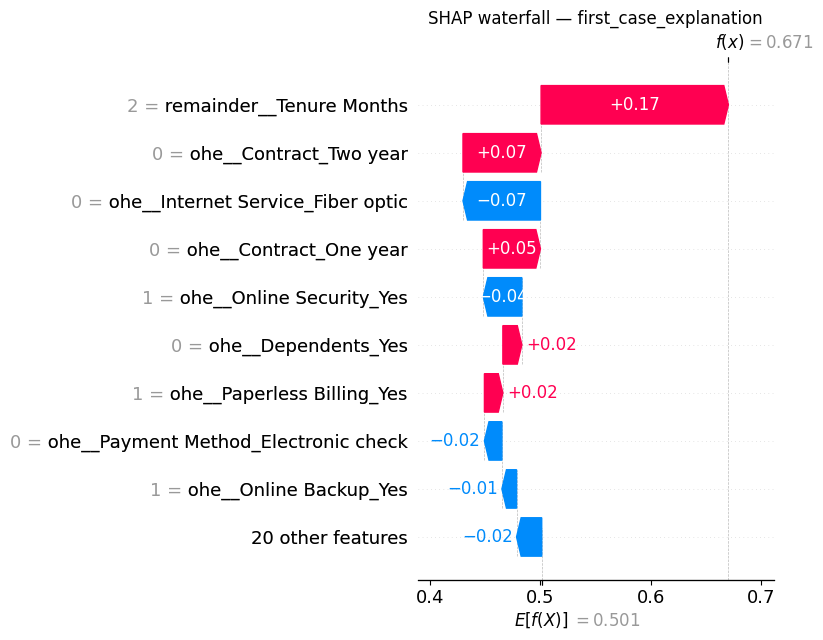

In [129]:
shap.waterfall_plot(shap.Explanation(
        values = shap_values[0, :, 1],
        base_values = explainer.expected_value[1],
        data = newX.iloc[0].values,
        feature_names = feature_names
    ), show = False)

plt.title('SHAP waterfall — first_case_explanation')
plt.tight_layout()
plt.savefig(BASE_PATH + 'first_case_explanation.png')
plt.show()

In [127]:
explainer.expected_value

array([0.49885622, 0.50114378])

In [133]:
Month_Outlier = newX[(newX['ohe__Contract_Two year'] == 0) & (newX['ohe__Contract_One year'] == 0) & (newX['remainder__Tenure Months'] > max_0)]
Twoyr_Outlier = newX[(newX['ohe__Contract_Two year'] == 1) & (newX['remainder__Tenure Months'] < min_2)]
Month_Y_Outlier = y[(newX['ohe__Contract_Two year'] == 0) & (newX['ohe__Contract_One year'] == 0) & (newX['remainder__Tenure Months'] > max_0)]
Twoyr_Y_Outlier = y[(newX['ohe__Contract_Two year'] == 1) & (newX['remainder__Tenure Months'] < min_2)]

In [147]:
Month_Outlier

,ohe__Gender_Male,ohe__Senior Citizen_Yes,ohe__Partner_Yes,ohe__Dependents_Yes,ohe__Phone Service_Yes,ohe__Multiple Lines_No phone service,ohe__Multiple Lines_Yes,ohe__Internet Service_Fiber optic,ohe__Internet Service_No,ohe__Online Security_No internet service,...,ohe__Streaming Movies_No internet service,ohe__Streaming Movies_Yes,ohe__Contract_One year,ohe__Contract_Two year,ohe__Paperless Billing_Yes,ohe__Payment Method_Credit card (automatic),ohe__Payment Method_Electronic check,ohe__Payment Method_Mailed check,remainder__Tenure Months,remainder__Monthly Charges
102,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,69.0,99.45
751,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,70.0,102.95
779,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,69.0,89.95
1149,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,69.0,103.95
1509,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,71.0,105.10
3114,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,70.0,97.55
3178,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,71.0,93.25
3374,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,69.0,85.40
3396,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,70.0,106.05
4682,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,72.0,112.90


In [146]:
Twoyr_Outlier

,ohe__Gender_Male,ohe__Senior Citizen_Yes,ohe__Partner_Yes,ohe__Dependents_Yes,ohe__Phone Service_Yes,ohe__Multiple Lines_No phone service,ohe__Multiple Lines_Yes,ohe__Internet Service_Fiber optic,ohe__Internet Service_No,ohe__Online Security_No internet service,...,ohe__Streaming Movies_No internet service,ohe__Streaming Movies_Yes,ohe__Contract_One year,ohe__Contract_Two year,ohe__Paperless Billing_Yes,ohe__Payment Method_Credit card (automatic),ohe__Payment Method_Electronic check,ohe__Payment Method_Mailed check,remainder__Tenure Months,remainder__Monthly Charges
1991,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,25.70
2048,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,10.0,29.60
2228,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,11.0,19.65
2234,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,52.55
2438,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,20.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6885,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,71.10
6891,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,8.0,19.05
6892,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,8.0,19.60
6916,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,8.0,65.50


In [144]:
Month_Y_Outlier.value_counts()

,count
Churn Value,
0,12
1,5


In [145]:
Twoyr_Y_Outlier.value_counts()

,count
Churn Value,
0,79
